['Royal Challengers Bengaluru' 'Punjab Kings' 'Delhi Capitals'
 'Mumbai Indians' 'Kolkata Knight Riders' 'Rajasthan Royals'
 'Sunrisers Hyderabad' 'Chennai Super Kings' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Gujarat Titans' 'Rising Pune Supergiants'
 'Lucknow Super Giants']
Total matches after cleaning: 1090
Any nulls left? 0
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Sunrisers Hyderabad            117
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Gujarat Titans                  41
Lucknow Super Giants            24
Rising Pune Supergiants         15
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


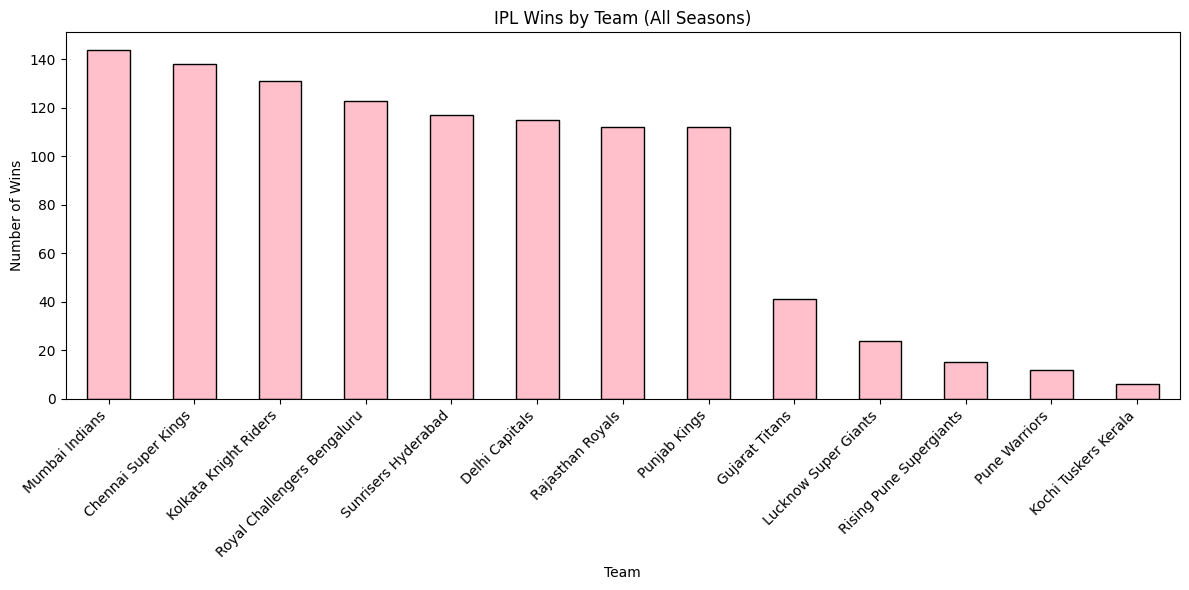

 
Toss winner wins the match 35.96330275229358 % of the time


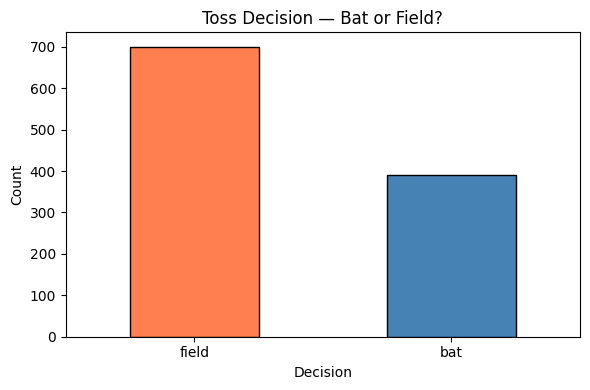

['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2', 'toss_match_winner']


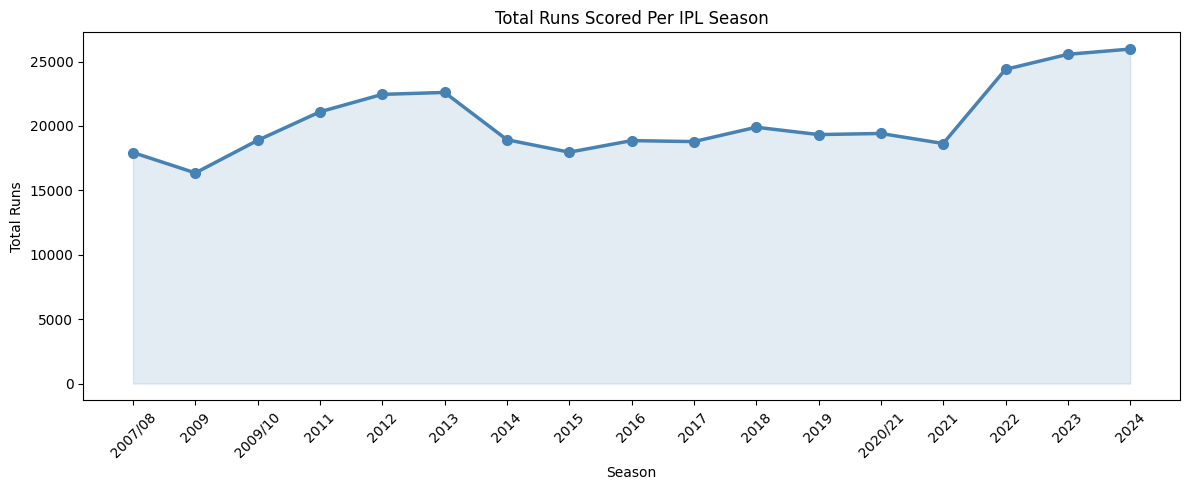

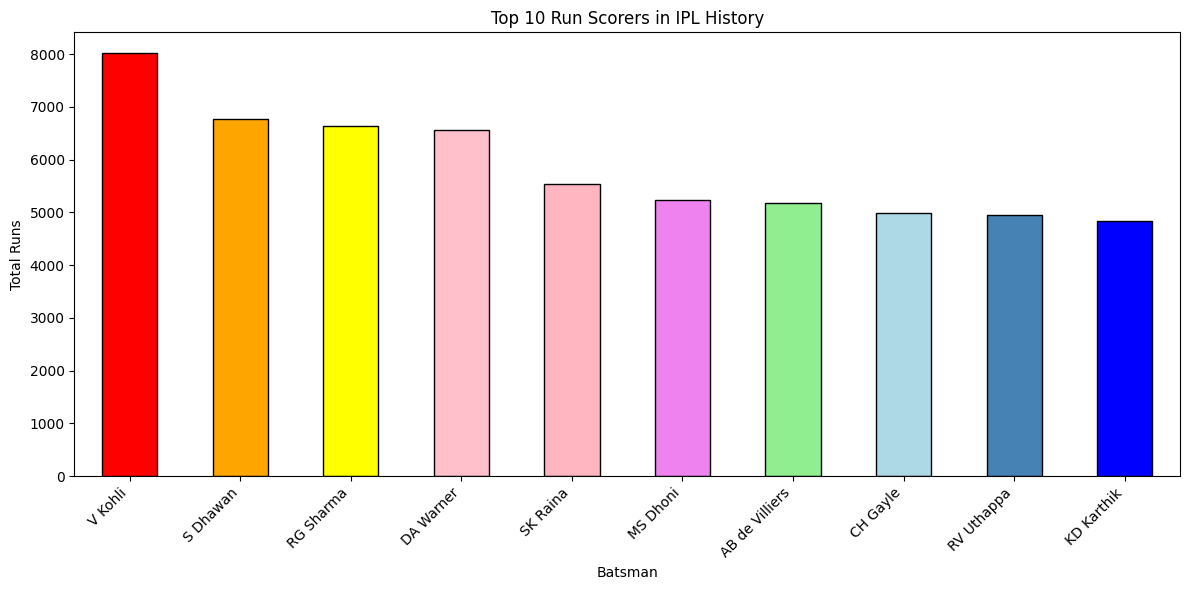

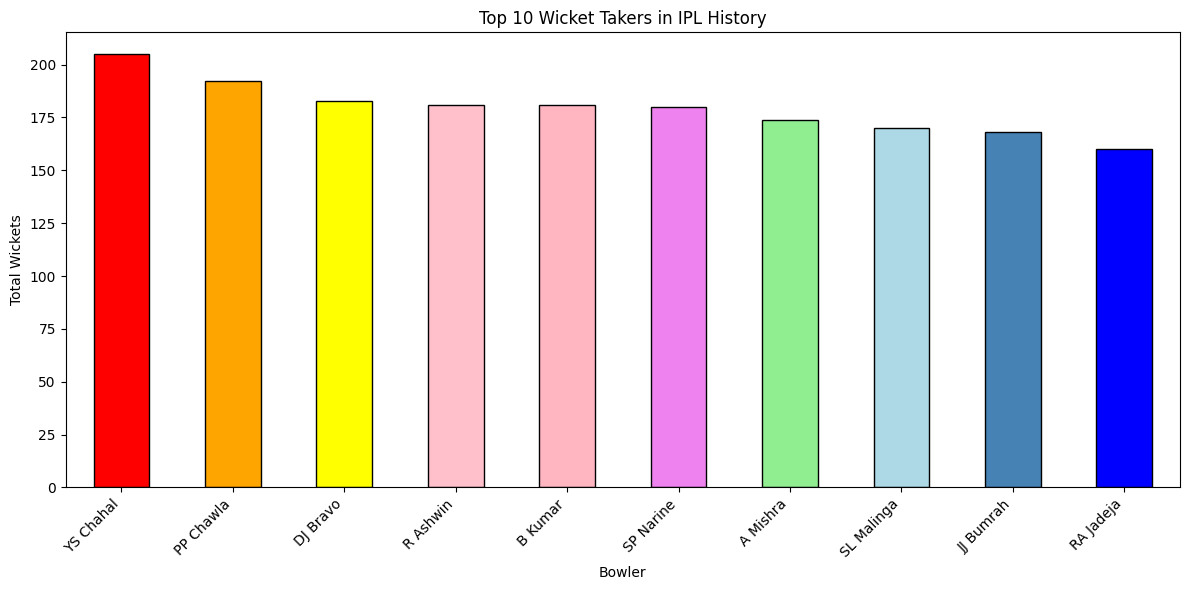

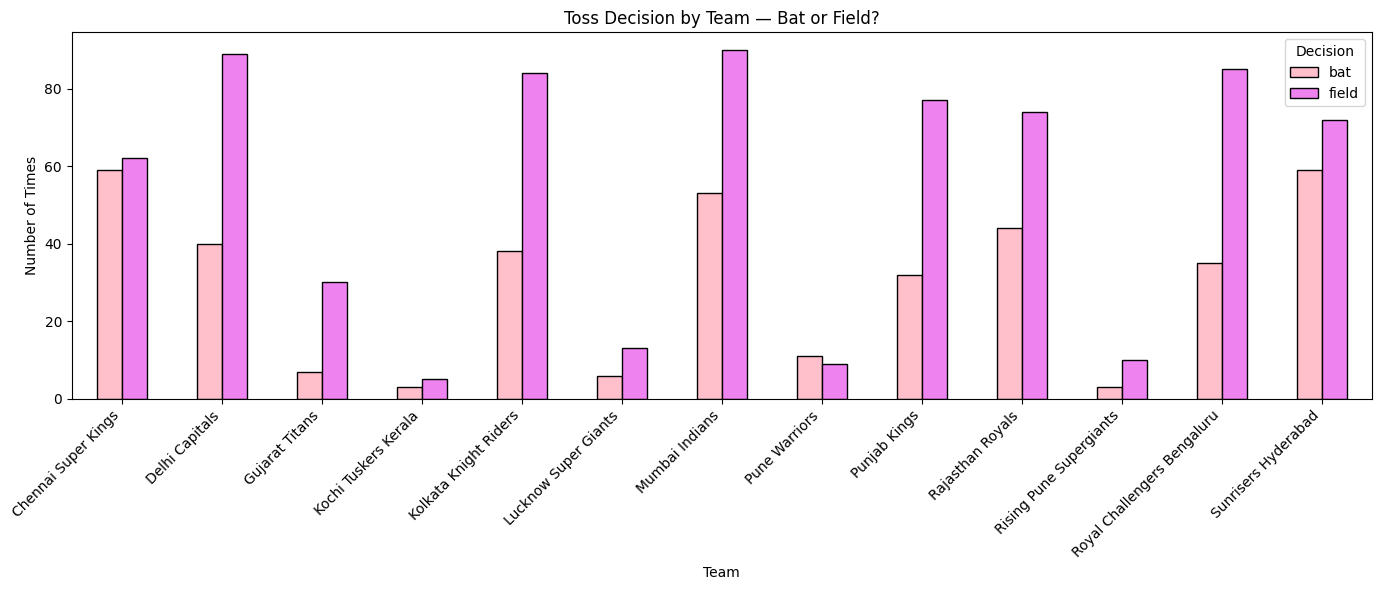

   team1  team2  toss_winner  toss_decision  venue  winner
0     11      4           11              1     23       4
1      8      0            0              0     40       0
2      1      9            9              0     16       1
3      6     11            6              0     55      11
4      4     12           12              0     14       4
(1090, 6)
Training samples: 872
Testing samples: 218
Accuracy: 50.917431192660544 %
Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']
Venues: ['Arun Jaitley Stadium', 'Arun Jaitley Stadium, Delhi', 'Barabati Stadium', 'Barsapara Cricket Stadium, Guwahati', 'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow', 'Brabourne Stadium', 'Brabourne Stadium, Mumbai', 'Buffalo Park', 'De Beer

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

matches = pd.read_csv('/content/matches.csv', on_bad_lines='skip')
deliveries = pd.read_csv('/content/deliveries.csv', on_bad_lines='skip')



#clean the data
matches = matches.dropna(subset=['winner'])
# replace old names with new ones
old_to_new = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Kings XI Punjab': 'Punjab Kings',
    'Gujarat Lions': 'Gujarat Titans',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}

matches['team1']  = matches['team1'].replace(old_to_new)
matches['team2']  = matches['team2'].replace(old_to_new)
matches['winner'] = matches['winner'].replace(old_to_new)


print(matches['team1'].unique())
print("Total matches after cleaning:", len(matches))
print("Any nulls left?", matches['winner'].isnull().sum())
# Most wins in IPL history
win_counts = matches['winner'].value_counts()
print(win_counts)

plt.figure(figsize=(12, 6))
win_counts.plot(kind='bar', color='pink', edgecolor='black')
plt.title('IPL Wins by Team (All Seasons)')
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#does winning the toss help the teams?
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']
toss_win_pct = matches['toss_match_winner'].mean() * 100
print(" ")
print("Toss winner wins the match", toss_win_pct,"%" , "of the time")

# whats more preferred: batting/ feilding ?
toss_decision = matches['toss_decision'].value_counts()

plt.figure(figsize=(6, 4))
toss_decision.plot(kind='bar', color=['coral', 'steelblue'], edgecolor='black')
plt.title('Toss Decision — Bat or Field?')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(deliveries.columns.tolist())
print(matches.columns.tolist())

deliveries.head()
# merging deliveries with matches to get the season info
season_runs = deliveries.merge(matches[['id', 'season']], left_on='match_id', right_on='id')
# total runs per season
season_total = season_runs.groupby('season')['total_runs'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(season_total['season'], season_total['total_runs'],
         marker='o', color='steelblue', linewidth=2.5, markersize=7)
plt.fill_between(season_total['season'], season_total['total_runs'], alpha=0.15, color='steelblue')
plt.title('Total Runs Scored Per IPL Season')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(season_total['season'], rotation=45)
plt.tight_layout()
plt.show()


# Top 10 batsmmen, depending on how many runs scored by all batsmen, then fetching the top 10
top_batsmen= deliveries.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
colors = ['red', 'orange','yellow',  'pink', 'lightpink', 'violet',
          'lightgreen', 'lightblue', 'steelblue', 'blue']
top_batsmen.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Top 10 Run Scorers in IPL History')
plt.xlabel('Batsman')
plt.ylabel('Total Runs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# filter only wicket deliveries, excluding run outs (bowler doesn't get credit)
wickets = deliveries[(deliveries['is_wicket'] == 1) &
                     (deliveries['dismissal_kind'] != 'run out')]

top_bowlers = wickets.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_bowlers.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Top 10 Wicket Takers in IPL History')
plt.xlabel('Bowler')
plt.ylabel('Total Wickets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


matches['toss_winner'] = matches['toss_winner'].replace(old_to_new) # replace old team names with new
# what each team prefers mostly: batting/bowling when the toss happened
toss = matches.groupby(['toss_winner', 'toss_decision']).size().unstack(fill_value=0)

toss.plot(kind='bar', figsize=(14, 6), color=['pink', 'violet'], edgecolor='black')
plt.title('Toss Decision by Team — Bat or Field?')
plt.xlabel('Team')
plt.ylabel('Number of Times')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Decision')
plt.tight_layout()
plt.show()

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

df = matches[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'winner']].copy()
#drop any null values:
df=df.dropna()
le_team=LabelEncoder()
le_venue=LabelEncoder()
le_decision= LabelEncoder()
df['team1'] = le_team.fit_transform(df['team1'])
df['team2'] = le_team.fit_transform(df['team2'])
df['toss_winner'] = le_team.fit_transform(df['toss_winner'])
df['venue'] = le_venue.fit_transform(df['venue'])
df['toss_decision'] = le_decision.fit_transform(df['toss_decision'])
df['winner'] = le_team.fit_transform(df['winner'])
print(df.head())
print(df.shape)
# X = inputs (what the model learns FROM)
# y = output (what the model is trying to PREDICT)
X = df[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']]
y = df['winner']

# 80% data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# testing  it
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")
import numpy as np

# predict: CSK vs MI at Wankhede, MI won toss and chose to field
# first check what numbers these teams got
print("Teams:", list(le_team.classes_))
print("Venues:", list(le_venue.classes_)[:10])
# CSK vs MI prediction
# Chennai Super Kings = 0, Mumbai Indians = 6
# for venue, let's find Wankhede- the exact name
print([v for v in le_venue.classes_ if 'Wankhede' in v])
# find the number for Wankhede Stadium, Mumbai
venue_name = 'Wankhede Stadium, Mumbai'
venue_num = list(le_venue.classes_).index(venue_name)
print("Wankhede number:", venue_num)

# CSK = 0, MI = 6
# MI won toss and chose to field (field = 0, bat = 1 — check with le_decision.classes_)
print("Toss decisions:", list(le_decision.classes_))


input_data = np.array([[0, 6, 6, 1, 56]])
# format: [team1, team2, toss_winner, toss_decision, venue]

prediction = model.predict(input_data)
predicted_winner = le_team.classes_[prediction[0]]
print("Predicted Winner:", predicted_winner)

# also get probability
proba = model.predict_proba(input_data)
print(f"CSK win probability: {proba[0][0]*100:.1f}%")
print(f"MI win probability: {proba[0][6]*100:.1f}%")

## 1. Importing Libraries and Loading Data
In this project, I've analyzed the IPL match data from 2008 to 2024. I used Pandas for data manipulation and data cleaning, NumPy for numerical operations, and Matplotlib for visualizations like the bar or line graph. The dataset contains two CSV files — matches.csv (one row per match) and deliveries.csv (one row per ball bowled).

## 2. Data Cleaning
Real-world datasets are rarely clean and are cluttered. Here, there were two issues:
1. Abandoned matches — Some matches have no winner due to rain or other reasons. These cases have been dropped, as they add no value to the analysis, and leave descreprencies.
2. Missing values — I've checked for any null values across all columns and removed incomplete rows before analysis.

## 3. Exploratory Data Analysis
Before building visualizations, exploring the structure of the dataset is extremely crucial. I checked the column names, data types, shape of the dataset, and basic statistics.
Key finding: the dataset contains 1090 valid matches across 13 franchises played at multiple venues across India and abroad.

## 4. Visualizations
These 5 key questions through visualizations have been answered:
1. Which team has won the most matches in IPL history?
2. How has total run scoring changed season by season?
3. Who are the top 10 run scorers of all time?
4. Who are the top 10 wicket takers of all time?
5. Do teams prefer batting or fielding after winning the toss?

## 5. Win Prediction Model
I built a Random Forest Classifier to predict the winner of an IPL match based on: team1, team2, toss winner, toss decision, and venue. Since team names and venues are text, we first convert them to numbers using Label Encoding. The model is trained on 80% of matches (872 matches) and tested on the remaining 20% (218 matches).
Accuracy achieved: ~50%
This reflects the inherently unpredictable nature of T20 cricket.
With richer features like player form, pitch conditions, and weather data, accuracy could improve significantly.

## 6. Predicting a Match
I've tested my model on a real matchup — CSK vs MI at Wankhede Stadium, with MI winning the toss and choosing to field.

Result: Model predicts ,MI as the winner.
The probabilities are distributed across all 13 teams since the model was trained as a multi-class classifier, not a binary one.